# Machine Learning Methods for Data Streams
## Project: Concept Drift Detection in Polarized News Streams

In [1]:
from river import compose, feature_extraction, naive_bayes, linear_model, optim, preprocessing, base
from sentence_transformers import SentenceTransformer

from src import run_experiment
from src import extract_max_n_per_class_per_day, undersample_stream, extract_and_split_minority_per_day
from src import plot_results

### 3. Real Data Experiments

In this section we test two classifiers that take the stream of news articles and predicts whether the article comes from a "Left" or "Right" news source. The classifiers are:

- Multinomial Naive Bayes + TF-IDF vectorizer
- Logistic Regression + LLM embeddings

We then apply ADWIN drift detector to the stream of classifier's errors and analyze the results.


The dataset collected in `01_web_scraping.ipynb` is highly imbalanced, with a significant majority of articles labeled as "Right". To address this imbalance, we developed three data preprocessing strategies:

- Extract max n per class per day: may produce unbalanced stream in case of days without articles from one of the classes; small loss of data.

- Under-sample the majority class: produces balanced stream but with significant loss of data.

- Split minority class: keep all articles from the majority side and split minority-class articles into parts so the number of parts matches the majority count, produces balanced stream without loss of data.

In [2]:
FILE_PATH = "data/news_dataset2.jsonl" 
with open(FILE_PATH, 'r', encoding='utf-8') as f:
    rows = f.readlines()

### Experiments

1. `max_n_per_class_per_day` + Multinomial Naive Bayes + TF-IDF vectorizer

In [3]:
tfidf_model = compose.Pipeline(
        ('vectorizer', feature_extraction.TFIDF(lowercase=True)),
        ('classifier', naive_bayes.MultinomialNB())
)

In [4]:
data_stream1 = extract_max_n_per_class_per_day(rows, n=3)

Days with at least 3 articles for both classes: 331
Days with undersampling (fewer than 3 articles for at least one class): 498
Total days processed: 829
Total Class 0 (Left) articles: 1539
Total Class 1 (Right) articles: 2331
Total articles in stream: 3870


In [4]:
dates1, accuracies1, majority_accuracies1, drifts_dates1 = run_experiment(data_stream1, tfidf_model)

Processed 100 articles.
Processed 200 articles.
Processed 300 articles.
Processed 400 articles.
Processed 500 articles.
Processed 600 articles.
Processed 700 articles.
Processed 800 articles.
Processed 900 articles.
Processed 1000 articles.
Processed 1100 articles.
Processed 1200 articles.
Processed 1300 articles.
Processed 1400 articles.
Processed 1500 articles.
Processed 1600 articles.
Processed 1700 articles.
Processed 1800 articles.
Processed 1900 articles.
Processed 2000 articles.
Processed 2100 articles.
Processed 2200 articles.
Processed 2300 articles.
Processed 2400 articles.
Processed 2500 articles.
Processed 2600 articles.
Processed 2700 articles.
Processed 2800 articles.
Processed 2900 articles.
Processed 3000 articles.
Processed 3100 articles.
Processed 3200 articles.
Processed 3300 articles.
Processed 3400 articles.
Processed 3500 articles.
Processed 3600 articles.
Processed 3700 articles.
Processed 3800 articles.


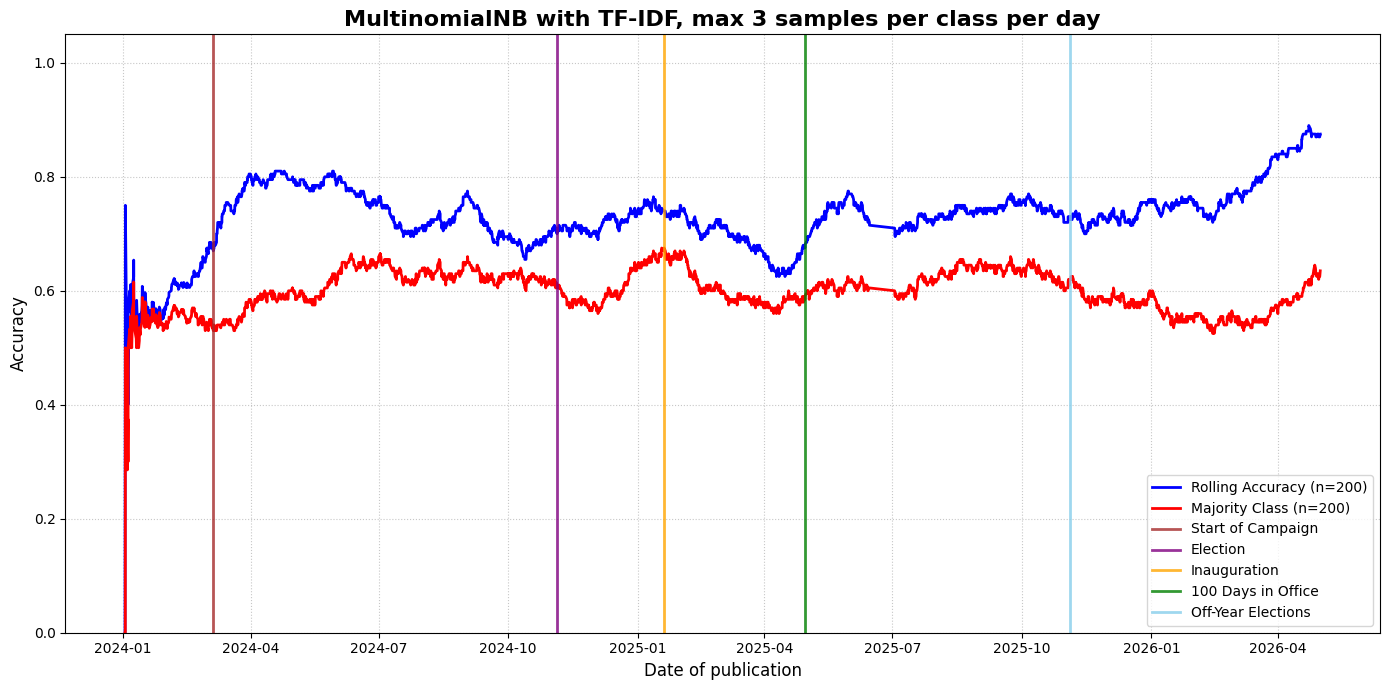

In [5]:
header1 = "MultinomialNB with TF-IDF, max 3 samples per class per day"
plot_results(dates1, accuracies1, majority_accuracies1, drifts_dates1, header1)

2. `undersample_stream` + Multinomial Naive Bayes + TF-IDF vectorizer

In [6]:
sorted_stream2 = undersample_stream(rows)

Total Class 0 (Left) articles before balancing: 2231
Total Class 1 (Right) articles before balancing: 12508
Total Class 0 (Left) articles after balancing: 2231
Total Class 1 (Right) articles after balancing: 2231
Total articles in stream: 4462


In [7]:
dates2, accuracies2, majority_accuracies2, drifts_dates2 = run_experiment(sorted_stream2, tfidf_model)

Processed 100 articles.
Processed 200 articles.
Processed 300 articles.
Processed 400 articles.
Processed 500 articles.
Processed 600 articles.
Detected Concept Drift on 2024-06-04
Processed 700 articles.
Processed 800 articles.
Processed 900 articles.
Processed 1000 articles.
Processed 1100 articles.
Processed 1200 articles.
Processed 1300 articles.
Processed 1400 articles.
Processed 1500 articles.
Processed 1600 articles.
Processed 1700 articles.
Processed 1800 articles.
Processed 1900 articles.
Processed 2000 articles.
Processed 2100 articles.
Processed 2200 articles.
Processed 2300 articles.
Processed 2400 articles.
Processed 2500 articles.
Processed 2600 articles.
Processed 2700 articles.
Processed 2800 articles.
Processed 2900 articles.
Processed 3000 articles.
Processed 3100 articles.
Processed 3200 articles.
Processed 3300 articles.
Processed 3400 articles.
Processed 3500 articles.
Processed 3600 articles.
Processed 3700 articles.
Processed 3800 articles.
Detected Concept Drift

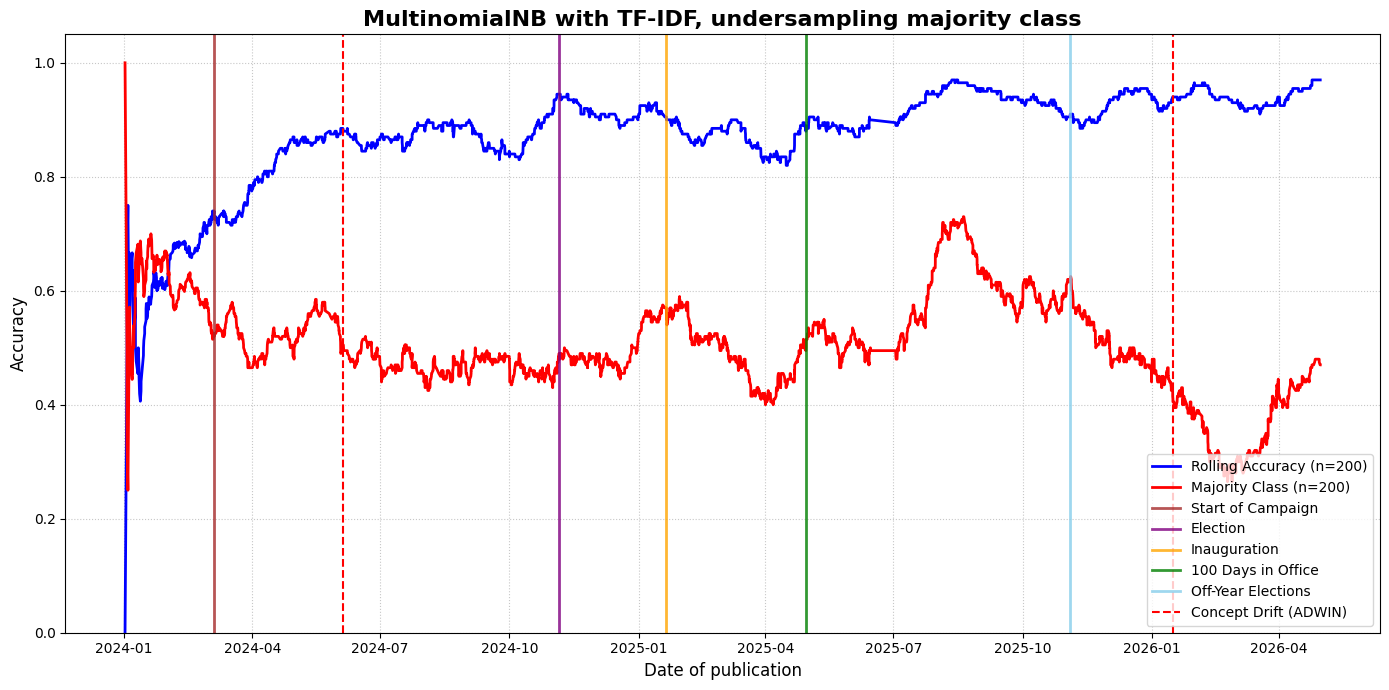

In [8]:
header2 = "MultinomialNB with TF-IDF, undersampling majority class"
plot_results(dates2, accuracies2, majority_accuracies2, drifts_dates2, header2)

3. `split_minority_class` + Model: Multinomial Naive Bayes + TF-IDF vectorizer

In [9]:
sorted_stream3 = extract_and_split_minority_per_day(rows)

Total days processed: 829
Days skipped (missing one class): 201
Majority class articles used: 10223
Minority class parts created: 10223
Total articles in stream: 20446


In [12]:
dates3, accuracies3, majority_accuracies3, drifts_dates3 = run_experiment(sorted_stream3, tfidf_model)

Processed 100 articles.
Processed 200 articles.
Processed 300 articles.
Processed 400 articles.
Processed 500 articles.
Processed 600 articles.
Processed 700 articles.
Processed 800 articles.
Processed 900 articles.
Processed 1000 articles.
Processed 1100 articles.
Detected Concept Drift on 2024-03-01
Processed 1200 articles.
Processed 1300 articles.
Processed 1400 articles.
Processed 1500 articles.
Processed 1600 articles.
Processed 1700 articles.
Processed 1800 articles.
Processed 1900 articles.
Processed 2000 articles.
Detected Concept Drift on 2024-04-07
Processed 2100 articles.
Processed 2200 articles.
Processed 2300 articles.
Processed 2400 articles.
Processed 2500 articles.
Processed 2600 articles.
Processed 2700 articles.
Processed 2800 articles.
Processed 2900 articles.
Processed 3000 articles.
Processed 3100 articles.
Processed 3200 articles.
Processed 3300 articles.
Processed 3400 articles.
Processed 3500 articles.
Processed 3600 articles.
Processed 3700 articles.
Processed 

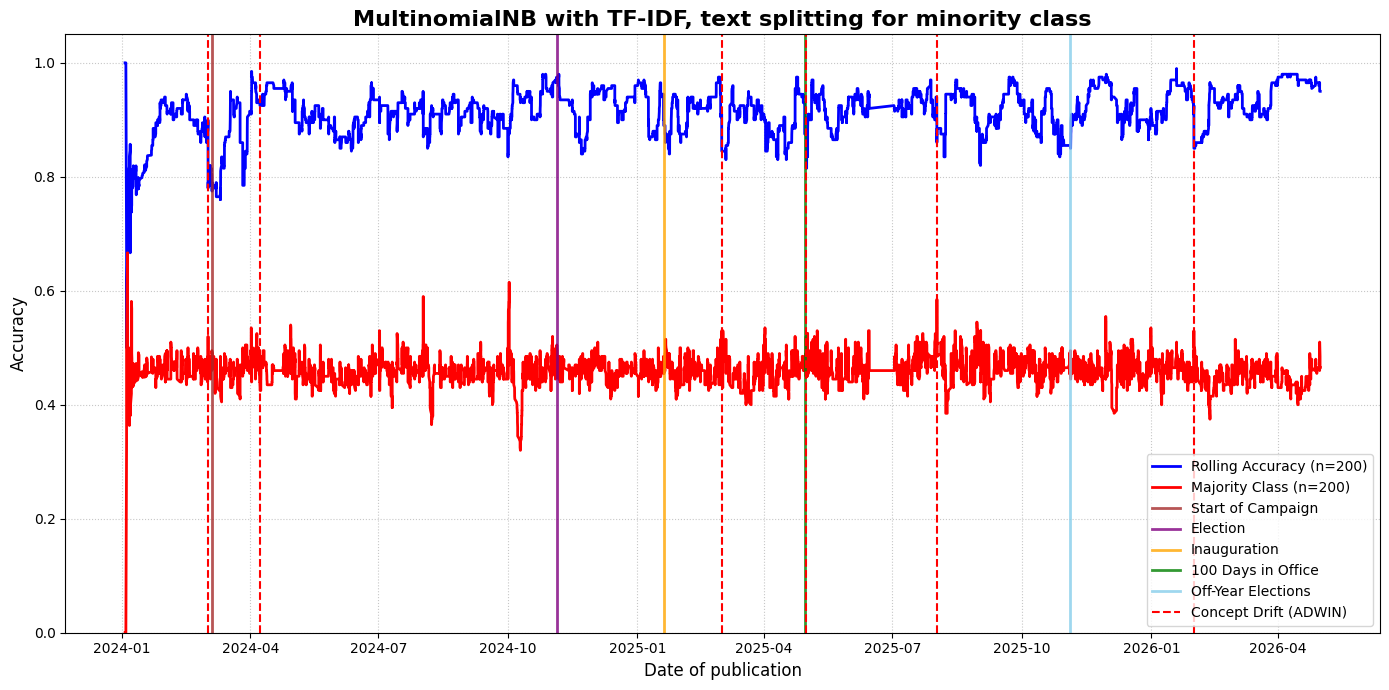

In [13]:
header3 = "MultinomialNB with TF-IDF, text splitting for minority class"
plot_results(dates3, accuracies3, majority_accuracies3, drifts_dates3, header3)

4. `max_n_per_class_per_day` + Logistic Regression + LLM embeddings

In [10]:
class StreamSentenceTransformer(base.Transformer):
    def __init__(self, model_name='all-MiniLM-L6-v2'):
        print(f"Loading SentenceTransformer model '{model_name}'...")
        self.encoder = SentenceTransformer(model_name)
        
    def transform_one(self, x):
        vector = self.encoder.encode(x)
        return {f"emb_{i}": float(val) for i, val in enumerate(vector)}

In [11]:
transformer_model = compose.Pipeline(
        ('vectorizer', StreamSentenceTransformer()),
        ('scaler', preprocessing.StandardScaler()),
        ('classifier', linear_model.LogisticRegression(optimizer=optim.SGD(0.05))) 
    )

Loading SentenceTransformer model 'all-MiniLM-L6-v2'...


README.md: 0.00B [00:00, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [23]:
data_stream1 = extract_max_n_per_class_per_day(rows, n=3)

Days with at least 3 articles for both classes: 331
Days with undersampling (fewer than 3 articles for at least one class): 498
Total days processed: 829
Total Class 0 (Left) articles: 1539
Total Class 1 (Right) articles: 2331
Total articles in stream: 3870


In [18]:
dates4, accuracies4, majority_accuracies4, drifts_dates4 = run_experiment(data_stream1, transformer_model)

Processed 100 articles.
Processed 200 articles.
Processed 300 articles.
Processed 400 articles.
Processed 500 articles.
Processed 600 articles.
Processed 700 articles.
Processed 800 articles.
Processed 900 articles.
Processed 1000 articles.
Processed 1100 articles.
Processed 1200 articles.
Processed 1300 articles.
Processed 1400 articles.
Processed 1500 articles.
Processed 1600 articles.
Processed 1700 articles.
Processed 1800 articles.
Processed 1900 articles.
Processed 2000 articles.
Processed 2100 articles.
Processed 2200 articles.
Processed 2300 articles.
Processed 2400 articles.
Processed 2500 articles.
Processed 2600 articles.
Processed 2700 articles.
Processed 2800 articles.
Processed 2900 articles.
Processed 3000 articles.
Processed 3100 articles.
Processed 3200 articles.
Processed 3300 articles.
Processed 3400 articles.
Processed 3500 articles.
Processed 3600 articles.
Processed 3700 articles.
Processed 3800 articles.


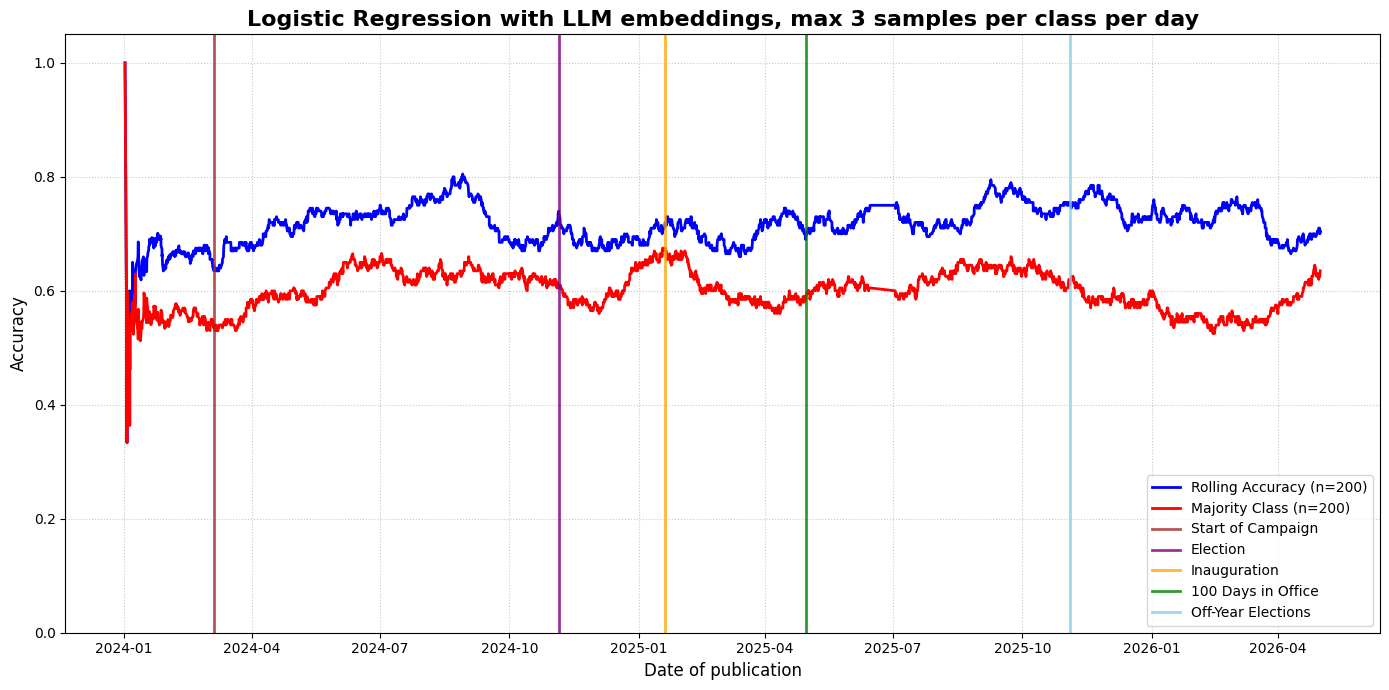

In [20]:
header4 = "Logistic Regression with LLM embeddings, max 3 samples per class per day"
plot_results(dates4, accuracies4, majority_accuracies4, drifts_dates4, header4)

5. `undersample_stream` + Logistic Regression + LLM embeddings

In [22]:
sorted_stream2 = undersample_stream(rows)

Total Class 0 (Left) articles before balancing: 2231
Total Class 1 (Right) articles before balancing: 12508
Total Class 0 (Left) articles after balancing: 2231
Total Class 1 (Right) articles after balancing: 2231
Total articles in stream: 4462


In [21]:
dates5, accuracies5, majority_accuracies5, drifts_dates5 = run_experiment(sorted_stream2, transformer_model)

Processed 100 articles.
Processed 200 articles.
Processed 300 articles.
Processed 400 articles.
Processed 500 articles.
Processed 600 articles.
Processed 700 articles.
Processed 800 articles.
Processed 900 articles.
Processed 1000 articles.
Processed 1100 articles.
Processed 1200 articles.
Processed 1300 articles.
Processed 1400 articles.
Processed 1500 articles.
Processed 1600 articles.
Processed 1700 articles.
Processed 1800 articles.
Processed 1900 articles.
Processed 2000 articles.
Processed 2100 articles.
Processed 2200 articles.
Processed 2300 articles.
Processed 2400 articles.
Processed 2500 articles.
Processed 2600 articles.
Processed 2700 articles.
Processed 2800 articles.
Processed 2900 articles.
Processed 3000 articles.
Processed 3100 articles.
Processed 3200 articles.
Processed 3300 articles.
Processed 3400 articles.
Processed 3500 articles.
Processed 3600 articles.
Processed 3700 articles.
Processed 3800 articles.
Processed 3900 articles.
Processed 4000 articles.
Processed

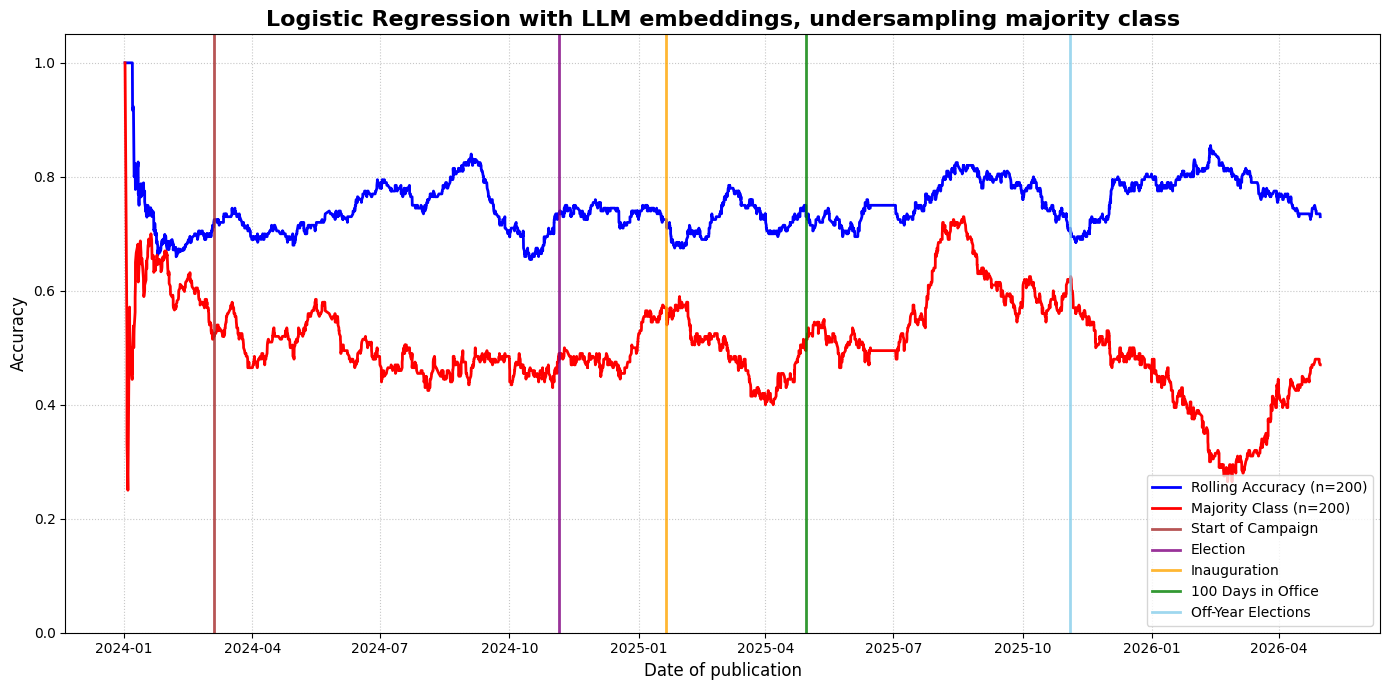

In [24]:
header5 = "Logistic Regression with LLM embeddings, undersampling majority class"
plot_results(dates5, accuracies5, majority_accuracies5, drifts_dates5, header5)

6. `split_minority_class` + Logistic Regression + LLM embeddings

In [25]:
sorted_stream3 = extract_and_split_minority_per_day(rows)

Total days processed: 829
Days skipped (missing one class): 201
Majority class articles used: 10223
Minority class parts created: 10223
Total articles in stream: 20446


In [26]:
dates6, accuracies6, majority_accuracies6, drifts_dates6 = run_experiment(sorted_stream3, transformer_model)

Processed 100 articles.
Processed 200 articles.
Processed 300 articles.
Processed 400 articles.
Processed 500 articles.
Processed 600 articles.
Processed 700 articles.
Processed 800 articles.
Processed 900 articles.
Processed 1000 articles.
Processed 1100 articles.
Processed 1200 articles.
Processed 1300 articles.
Processed 1400 articles.
Processed 1500 articles.
Processed 1600 articles.
Processed 1700 articles.
Processed 1800 articles.
Processed 1900 articles.
Processed 2000 articles.
Processed 2100 articles.
Processed 2200 articles.
Processed 2300 articles.
Processed 2400 articles.
Processed 2500 articles.
Processed 2600 articles.
Processed 2700 articles.
Processed 2800 articles.
Processed 2900 articles.
Processed 3000 articles.
Processed 3100 articles.
Processed 3200 articles.
Processed 3300 articles.
Processed 3400 articles.
Processed 3500 articles.
Processed 3600 articles.
Processed 3700 articles.
Processed 3800 articles.
Detected Concept Drift on 2024-07-01
Processed 3900 article

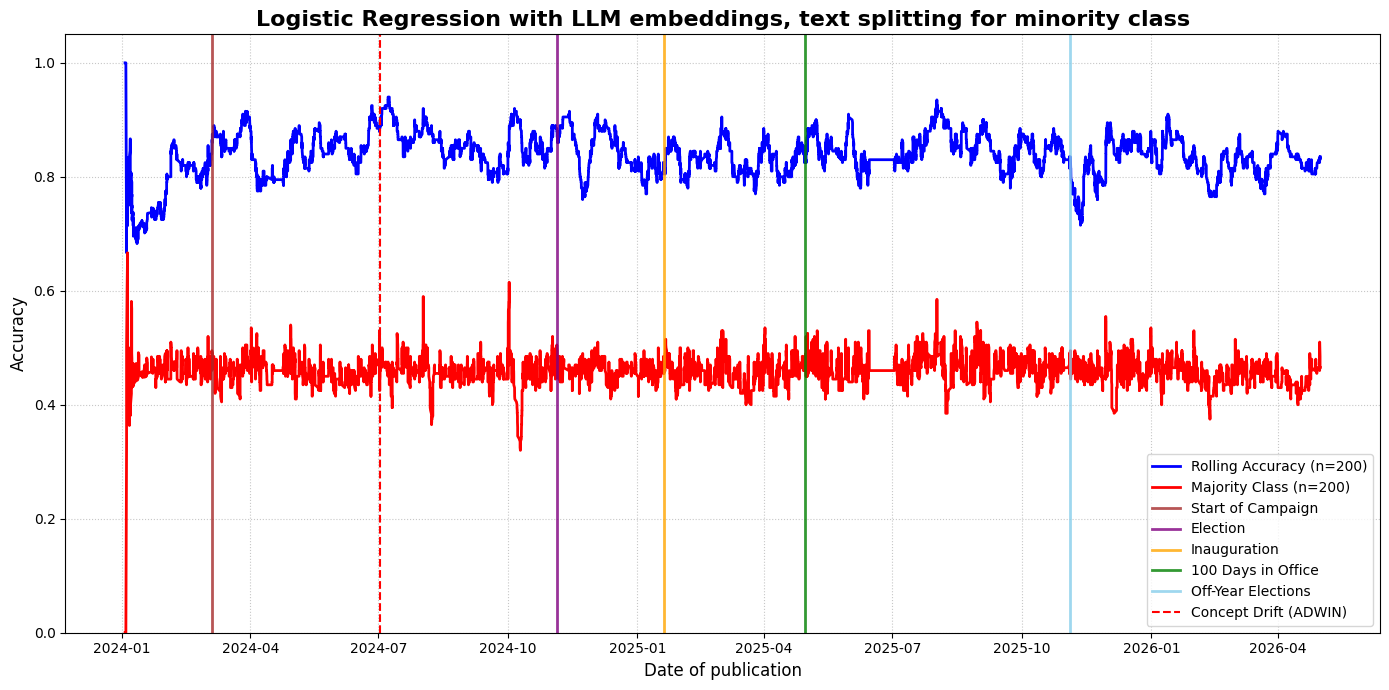

In [27]:
header6 = "Logistic Regression with LLM embeddings, text splitting for minority class"
plot_results(dates6, accuracies6, majority_accuracies6, drifts_dates6, header6)

7. `split_minority_class` + Logistic Regression + PoliticalBiasBERT embeddings

In [35]:
political_transformers_model = compose.Pipeline(
        ('vectorizer', StreamSentenceTransformer('bucketresearch/politicalBiasBERT')),
        ('scaler', preprocessing.StandardScaler()),
        ('classifier', linear_model.LogisticRegression(optimizer=optim.SGD(0.05))) 
    )

Loading SentenceTransformer model 'bucketresearch/politicalBiasBERT'...


No sentence-transformers model found with name bucketresearch/politicalBiasBERT. Creating a new one with mean pooling.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bucketresearch/politicalBiasBERT
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 
classifier.weight            | UNEXPECTED |  | 
classifier.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [36]:
data_stream3 = extract_and_split_minority_per_day(rows)

Total days processed: 829
Days skipped (missing one class): 201
Majority class articles used: 10223
Minority class parts created: 10223
Total articles in stream: 20446


In [37]:
dates7, accuracies7, majority_accuracies7, drifts_dates7 = run_experiment(sorted_stream3, political_transformers_model)

Processed 100 articles.
Processed 200 articles.
Processed 300 articles.
Processed 400 articles.
Processed 500 articles.
Processed 600 articles.
Processed 700 articles.
Processed 800 articles.
Processed 900 articles.
Processed 1000 articles.
Processed 1100 articles.
Detected Concept Drift on 2024-03-01
Processed 1200 articles.
Processed 1300 articles.
Processed 1400 articles.
Processed 1500 articles.
Processed 1600 articles.
Processed 1700 articles.
Processed 1800 articles.
Processed 1900 articles.
Processed 2000 articles.
Processed 2100 articles.
Processed 2200 articles.
Processed 2300 articles.
Processed 2400 articles.
Processed 2500 articles.
Processed 2600 articles.
Processed 2700 articles.
Processed 2800 articles.
Processed 2900 articles.
Processed 3000 articles.
Processed 3100 articles.
Processed 3200 articles.
Processed 3300 articles.
Processed 3400 articles.
Processed 3500 articles.
Processed 3600 articles.
Processed 3700 articles.
Processed 3800 articles.
Processed 3900 article

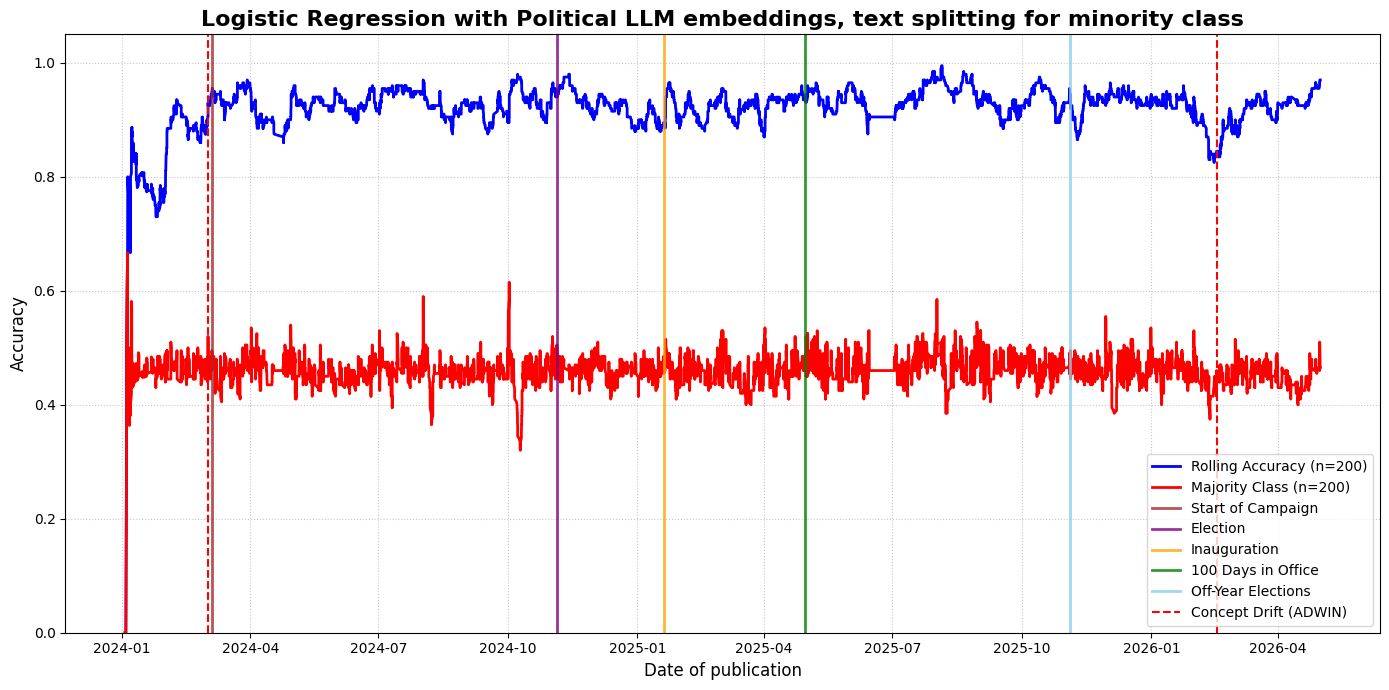

In [38]:
header7 = "Logistic Regression with Political LLM embeddings, text splitting for minority class"
plot_results(dates7, accuracies7, majority_accuracies7, drifts_dates7, header7)

### Accuracy comparsion

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_comparsion(accuracies_list, labels, header):
    plt.figure(figsize=(14, 7))
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']
    
    max_len = max(len(accuracies) for accuracies in accuracies_list)
    
    for idx, accuracies in enumerate(accuracies_list):
        color = colors[idx % len(colors)]
        x_stretched = np.linspace(0, max_len, len(accuracies))
        plt.plot(x_stretched, accuracies, label=labels[idx], color=color, linewidth=1.5)

    plt.title(f'{header}', fontsize=16, fontweight='bold')
    
    plt.xlabel('Normalized Timeline', fontsize=12)
    plt.ylabel('Rolling Accuracy (Window=200)', fontsize=12)
    plt.ylim(0.35, 1.05)
    
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()

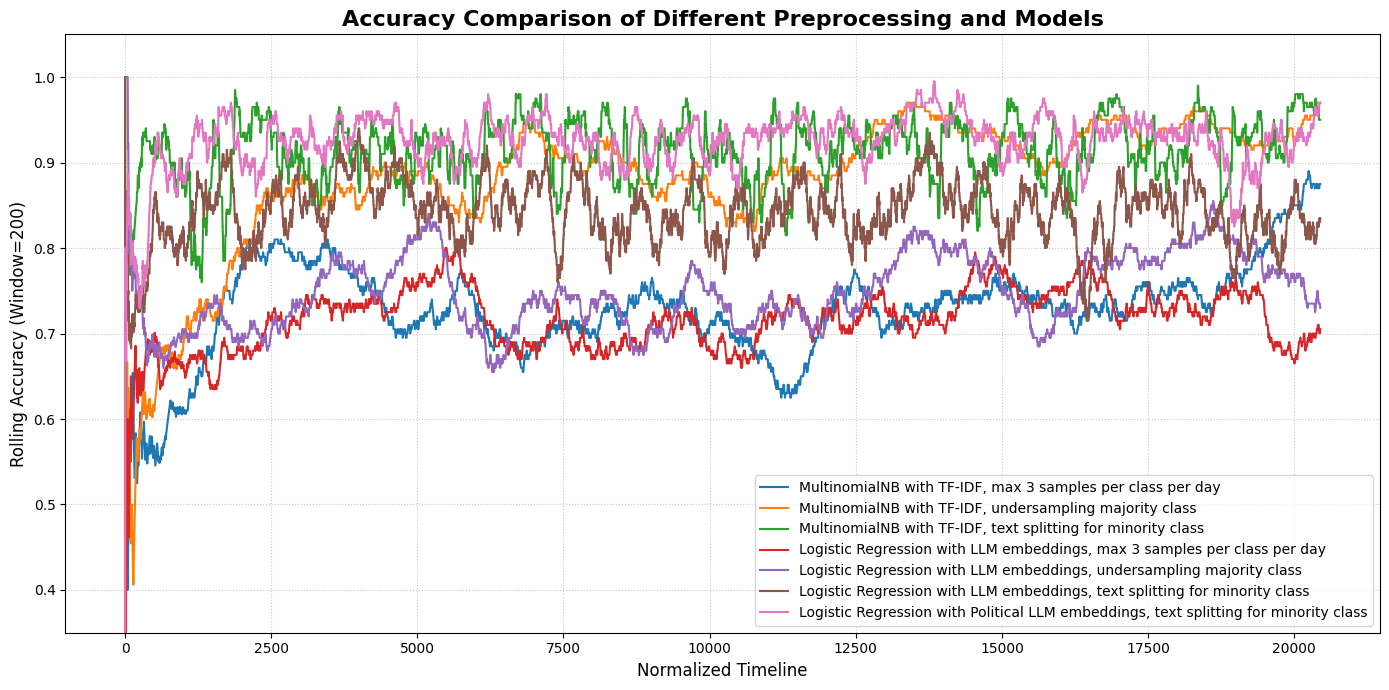

In [43]:
plot_comparsion([accuracies1, accuracies2, accuracies3, accuracies4, accuracies5, accuracies6, accuracies7],
                [header1, header2, header3, header4, header5, header6, header7],
                "Accuracy Comparison of Different Preprocessing and Models")

### Not sufficient data volume test

In [5]:
data_stream_low = extract_max_n_per_class_per_day(rows, n=1)

Days with at least 1 articles for both classes: 628
Days with undersampling (fewer than 1 articles for at least one class): 201
Total days processed: 829
Total Class 0 (Left) articles: 669
Total Class 1 (Right) articles: 788
Total articles in stream: 1457


In [14]:
dates_low, accuracies_low, majority_accuracies_low, drifts_dates_low = run_experiment(data_stream_low, tfidf_model)

Processed 100 articles.
Processed 200 articles.
Processed 300 articles.
Processed 400 articles.
Processed 500 articles.
Processed 600 articles.
Processed 700 articles.
Processed 800 articles.
Processed 900 articles.
Processed 1000 articles.
Processed 1100 articles.
Processed 1200 articles.
Processed 1300 articles.
Processed 1400 articles.


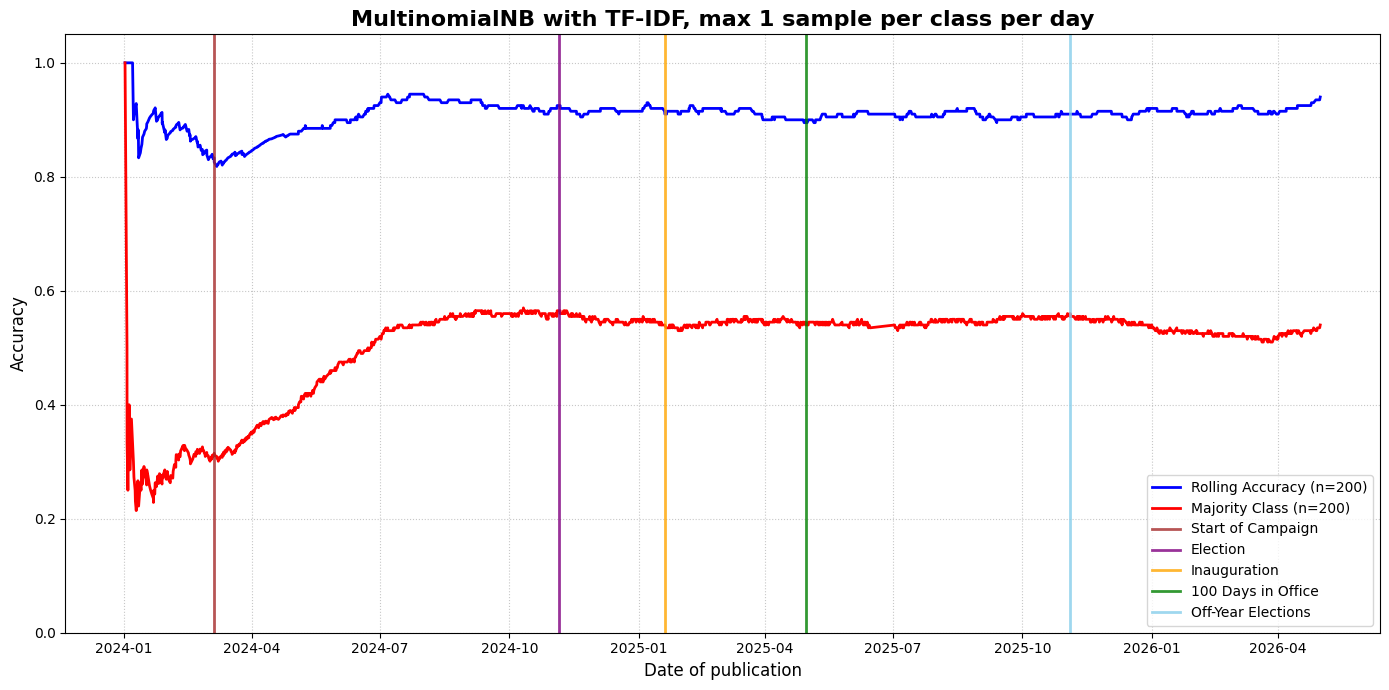

In [15]:
header_low = "MultinomialNB with TF-IDF, max 1 sample per class per day"
plot_results(dates_low, accuracies_low, majority_accuracies_low, drifts_dates_low, header_low)